In [1]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import KFold, cross_val_score

from scipy.stats import spearmanr, pearsonr
from statsmodels.stats.multitest import multipletests

In [39]:
with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/sim47.pkl", "rb") as f:
    all_results = pickle.load(f)

with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/mc_measureslora47.pkl", "rb") as f:
    mc_measures = pickle.load(f)

with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/mc_measures1.4.pkl", "rb") as f:
    mc_measures_no_lora = pickle.load(f)

In [3]:
print(all_results.keys())
print(all_results[1][2222].keys())
print(mc_measures.keys())

dict_keys([1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 22, 23, 24, 27, 28, 29, 30, 33, 35, 36, 38, 39, 40, 41, 42, 43, 45, 47, 49])
dict_keys(['raw_score', 'lenweighted_score', 'reward_min', 'len'])
dict_keys(['orth_vec_thresh_crossed_not_norm', 'MC_singular_components_svd'])


In [40]:
mc_measures_no_lora.keys()

dict_keys(['tau_orth_vec', 'tau_orth_vec_not_norm', 'orth_vec_thresh_crossed', 'orth_vec_thresh_crossed_not_norm', 'norm_thresh_crossed', 'summed_MC_svd', 'MC_singular_components_svd', 'MC_singular_components_hs_svd', 'participation_ratio_svd'])

In [4]:
weight_trials = [1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 17, 18, 22, 23, 24, 27, 28, 29, 30, 33, 35, 36, 38, 39, 40, 41, 42, 43, 45, 47, 49]
n_seeds = 3
seeds = [1111, 2222, 3333, 4444, 5555]
n_policies = 4

sorted_weight_trials = sorted(weight_trials)

time_interval = [80000000,100000000]

In [6]:
mean_results = dict()

for trial in weight_trials:
    mean_results_by_seeds = {1111:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                2222:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                3333:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None},
                4444:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None},
                5555:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}}
    for seed in seeds:
        raw = all_results[trial][seed]['raw_score']
        if raw is not None:
            mean_results_by_seeds[seed]['raw_score'] = raw.mean(axis=1)

        lw = all_results[trial][seed]['lenweighted_score']
        if lw is not None:
            mean_results_by_seeds[seed]['lenweighted_score'] = lw.mean(axis=1)

        rmin = all_results[trial][seed]['reward_min']
        if rmin is not None:
            mean_results_by_seeds[seed]['reward_min'] = rmin.mean(axis=1)

        l = all_results[trial][seed]['len']
        if l is not None:
            mean_results_by_seeds[seed]['len'] = l.mean(axis=1)
    mean_results[trial] = mean_results_by_seeds
    


In [7]:
print(mean_results[1][1111]['raw_score'].to_list())
print(len(mean_results[1][seed]['raw_score'].index.to_list()))

[0.7375, 0.7625, 0.7625, 0.8125, 0.8, 0.73125, 0.7125, 0.65, 0.6166666666666667, 0.65, 0.6916666666666667, 0.6958333333333333, 0.675, 0.65, 0.65, 0.6208333333333333, 0.61875, 0.625, 0.6166666666666667, 0.5875, 0.5854166666666667, 0.6083333333333334, 0.625, 0.5833333333333334, 0.6208333333333333, 0.625, 0.625, 0.6, 0.575, 0.575, 0.5125, 0.5125, 0.48125, 0.4999999999999999, 0.49999999999999994, 0.55, 0.5583333333333333, 0.55, 0.5375000000000001, 0.5125, 0.475, 0.425, 0.4375, 0.425, 0.425, 0.43333333333333335, 0.42499999999999993, 0.42500000000000004, 0.42500000000000004, 0.4, 0.44166666666666665, 0.4125, 0.49166666666666664, 0.5083333333333333, 0.5375, 0.5375, 0.575, 0.6375000000000001, 0.6895833333333334, 0.75, 0.7749999999999999, 0.7749999999999999, 0.7999999999999999, 0.8375, 0.875, 0.9625, 1.0250000000000001, 1.1125, 1.25, 1.29375, 1.3499999999999999, 1.475, 1.5291666666666668, 1.525, 1.6375000000000002, 1.58125, 1.5875, 1.625, 1.5875, 1.5, 1.6124999999999998, 1.75, 1.825, 1.89166666

In [20]:
for trial in weight_trials:
    for seed in seeds:
        s = mean_results[trial][seed]['raw_score']
        if s is None or s.empty:
            continue
        last_idx = s.index[-1]
        if last_idx<80000000:
            print(last_idx)

79830000.0
58650000.0
77460000.0
72810000.0
75510000.0
68640000.0
78330000.0
76980000.0
73260000.0
78570000.0


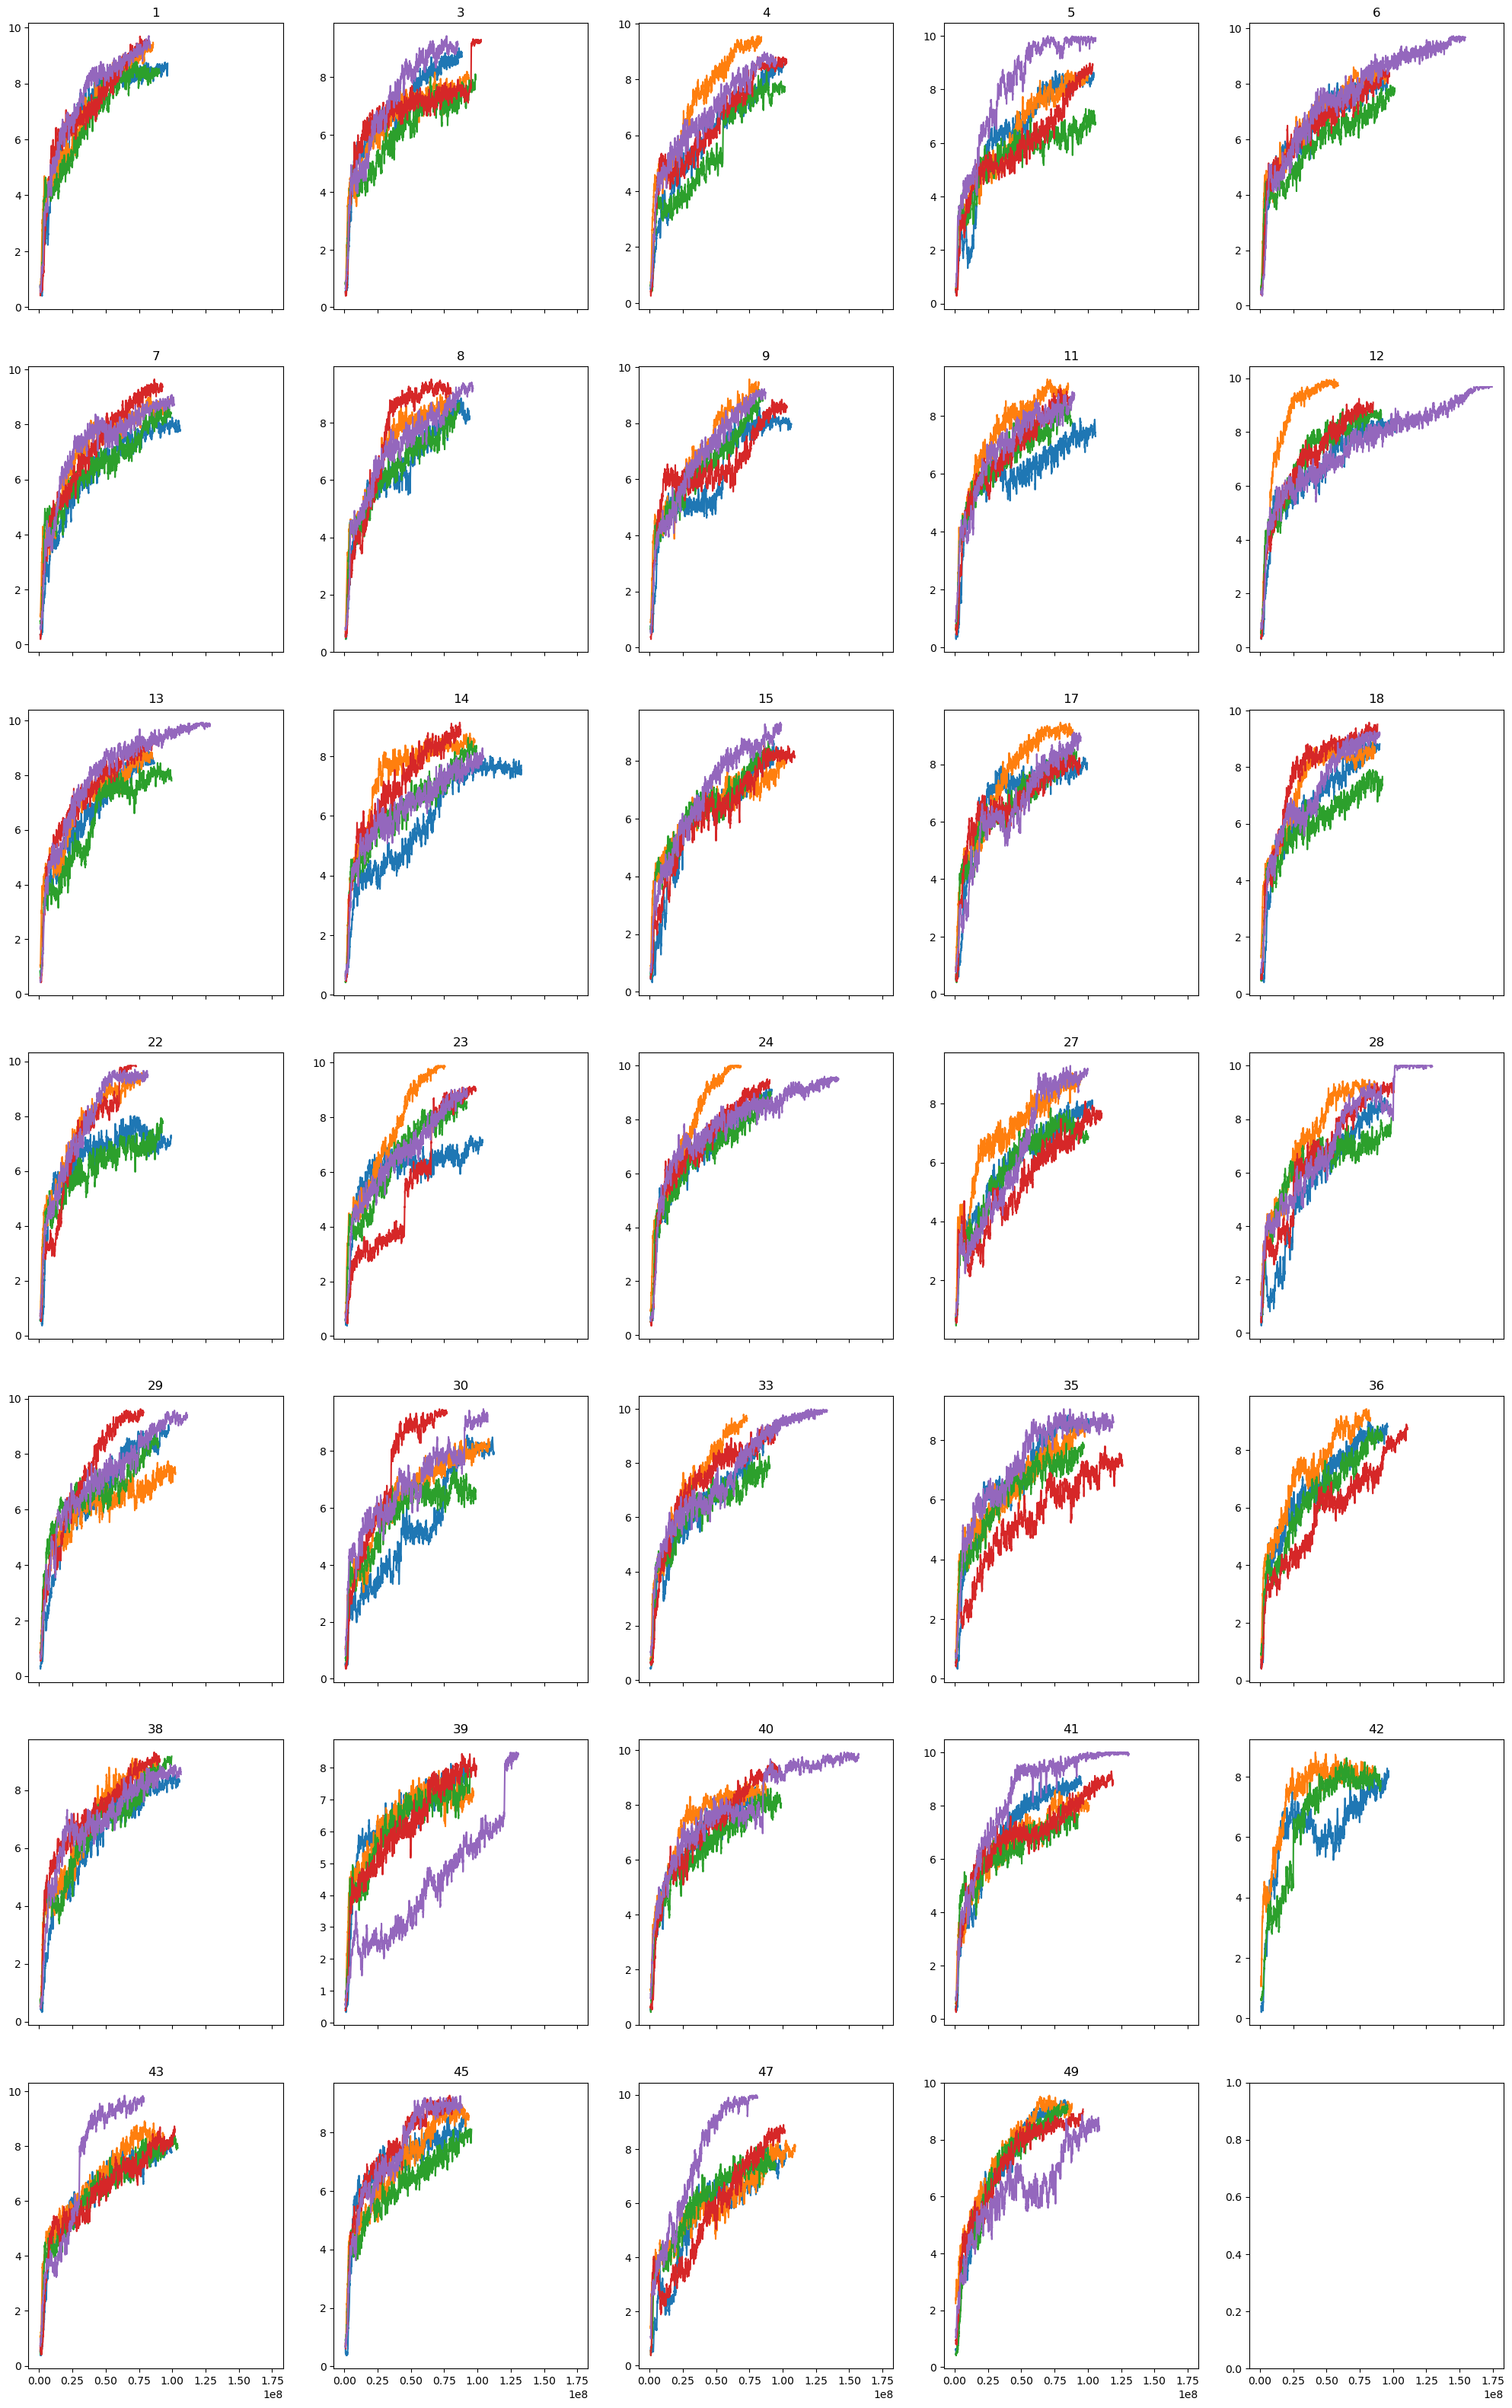

In [9]:
fig, ax = plt.subplots(7,5, figsize=(25,40), sharex=True)
for i,t in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        raw_score = mean_results[t][seed]['raw_score']
        if raw_score is None:
            continue
        idx = mean_results[t][seed]['raw_score'].index.to_list()
        ax[i//5, i%5].plot(idx, raw_score)
        ax[i//5, i%5].set_title(f'{t}')

In [32]:
# take the mean of a metric for the relevant time interval
# mean raw score time inverval has the format (trial,seed)
mean_raw_score_time_interval = dict()
for i, trial in enumerate(weight_trials):
    mean_raw_score_time_interval[trial] = dict()
    for seed in seeds:
        raw_score = mean_results[trial][seed]['raw_score']
        s = mean_results[trial][seed]['raw_score']
        if s is None or s.empty:
            mean_raw_score_time_interval[trial][seed] = None
            continue
        last_idx = s.index[-1]
        if last_idx<80000000:
            mean_raw_score_time_interval[trial][seed] = s[s.index[-1]]
        raw_score_time_interval = raw_score[time_interval[0]:time_interval[1]]
        mean_raw_score_time_interval[trial][seed] = raw_score_time_interval.mean()

/tmp/ipykernel_1587391/167999813.py:15: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  raw_score_time_interval = raw_score[time_interval[0]:time_interval[1]]


In [22]:
print(mean_raw_score_time_interval[1].keys())
print(mean_raw_score_time_interval[1][2222])

dict_keys([1111, 2222, 3333, 4444, 5555])
9.258548223161318


In [25]:
colors = ['b', 'g', 'r', 'c', 'k']

In [28]:
mc_measures['orth_vec_thresh_crossed_not_norm'][36][5555]

np.int64(17)

In [31]:
mean_raw_score_time_interval[36]

{1111: np.float64(8.613984417966728),
 2222: np.float64(9.175122123015871),
 3333: np.float64(8.441471716412657),
 4444: np.float64(7.529914344775662)}

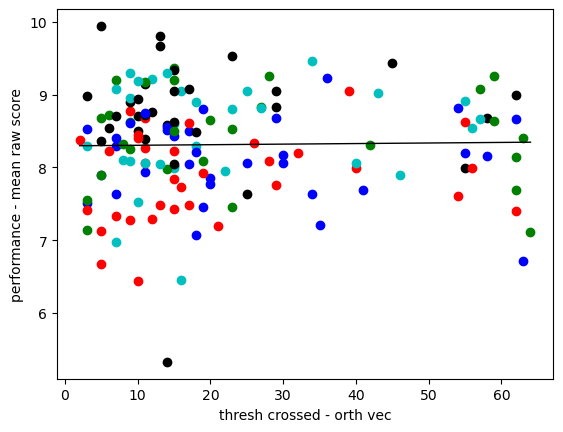

In [44]:
plt.figure()
#plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
for i,trial in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        if mean_raw_score_time_interval[trial][seed] == None:
            continue
        plt.scatter(mc_measures['orth_vec_thresh_crossed_not_norm'][trial][seed] - mc_measures_no_lora['orth_vec_thresh_crossed_not_norm'][i], mean_raw_score_time_interval[trial][seed], c=colors[j])
plt.xlabel('thresh crossed - orth vec')
plt.ylabel('performance - mean raw score')


# fit a linear regression
x, y = [], []
for i, trial in enumerate(weight_trials):
    for seed in seeds:
        x.append(mc_measures['orth_vec_thresh_crossed_not_norm'][trial][seed] - mc_measures_no_lora['orth_vec_thresh_crossed_not_norm'][i])
        y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

reg = LinearRegression().fit(x.reshape(-1, 1), y)
x = np.linspace(x.min(), x.max(), 200)
plt.plot(x, reg.coef_[0]*x + reg.intercept_, color='black', linewidth=1)

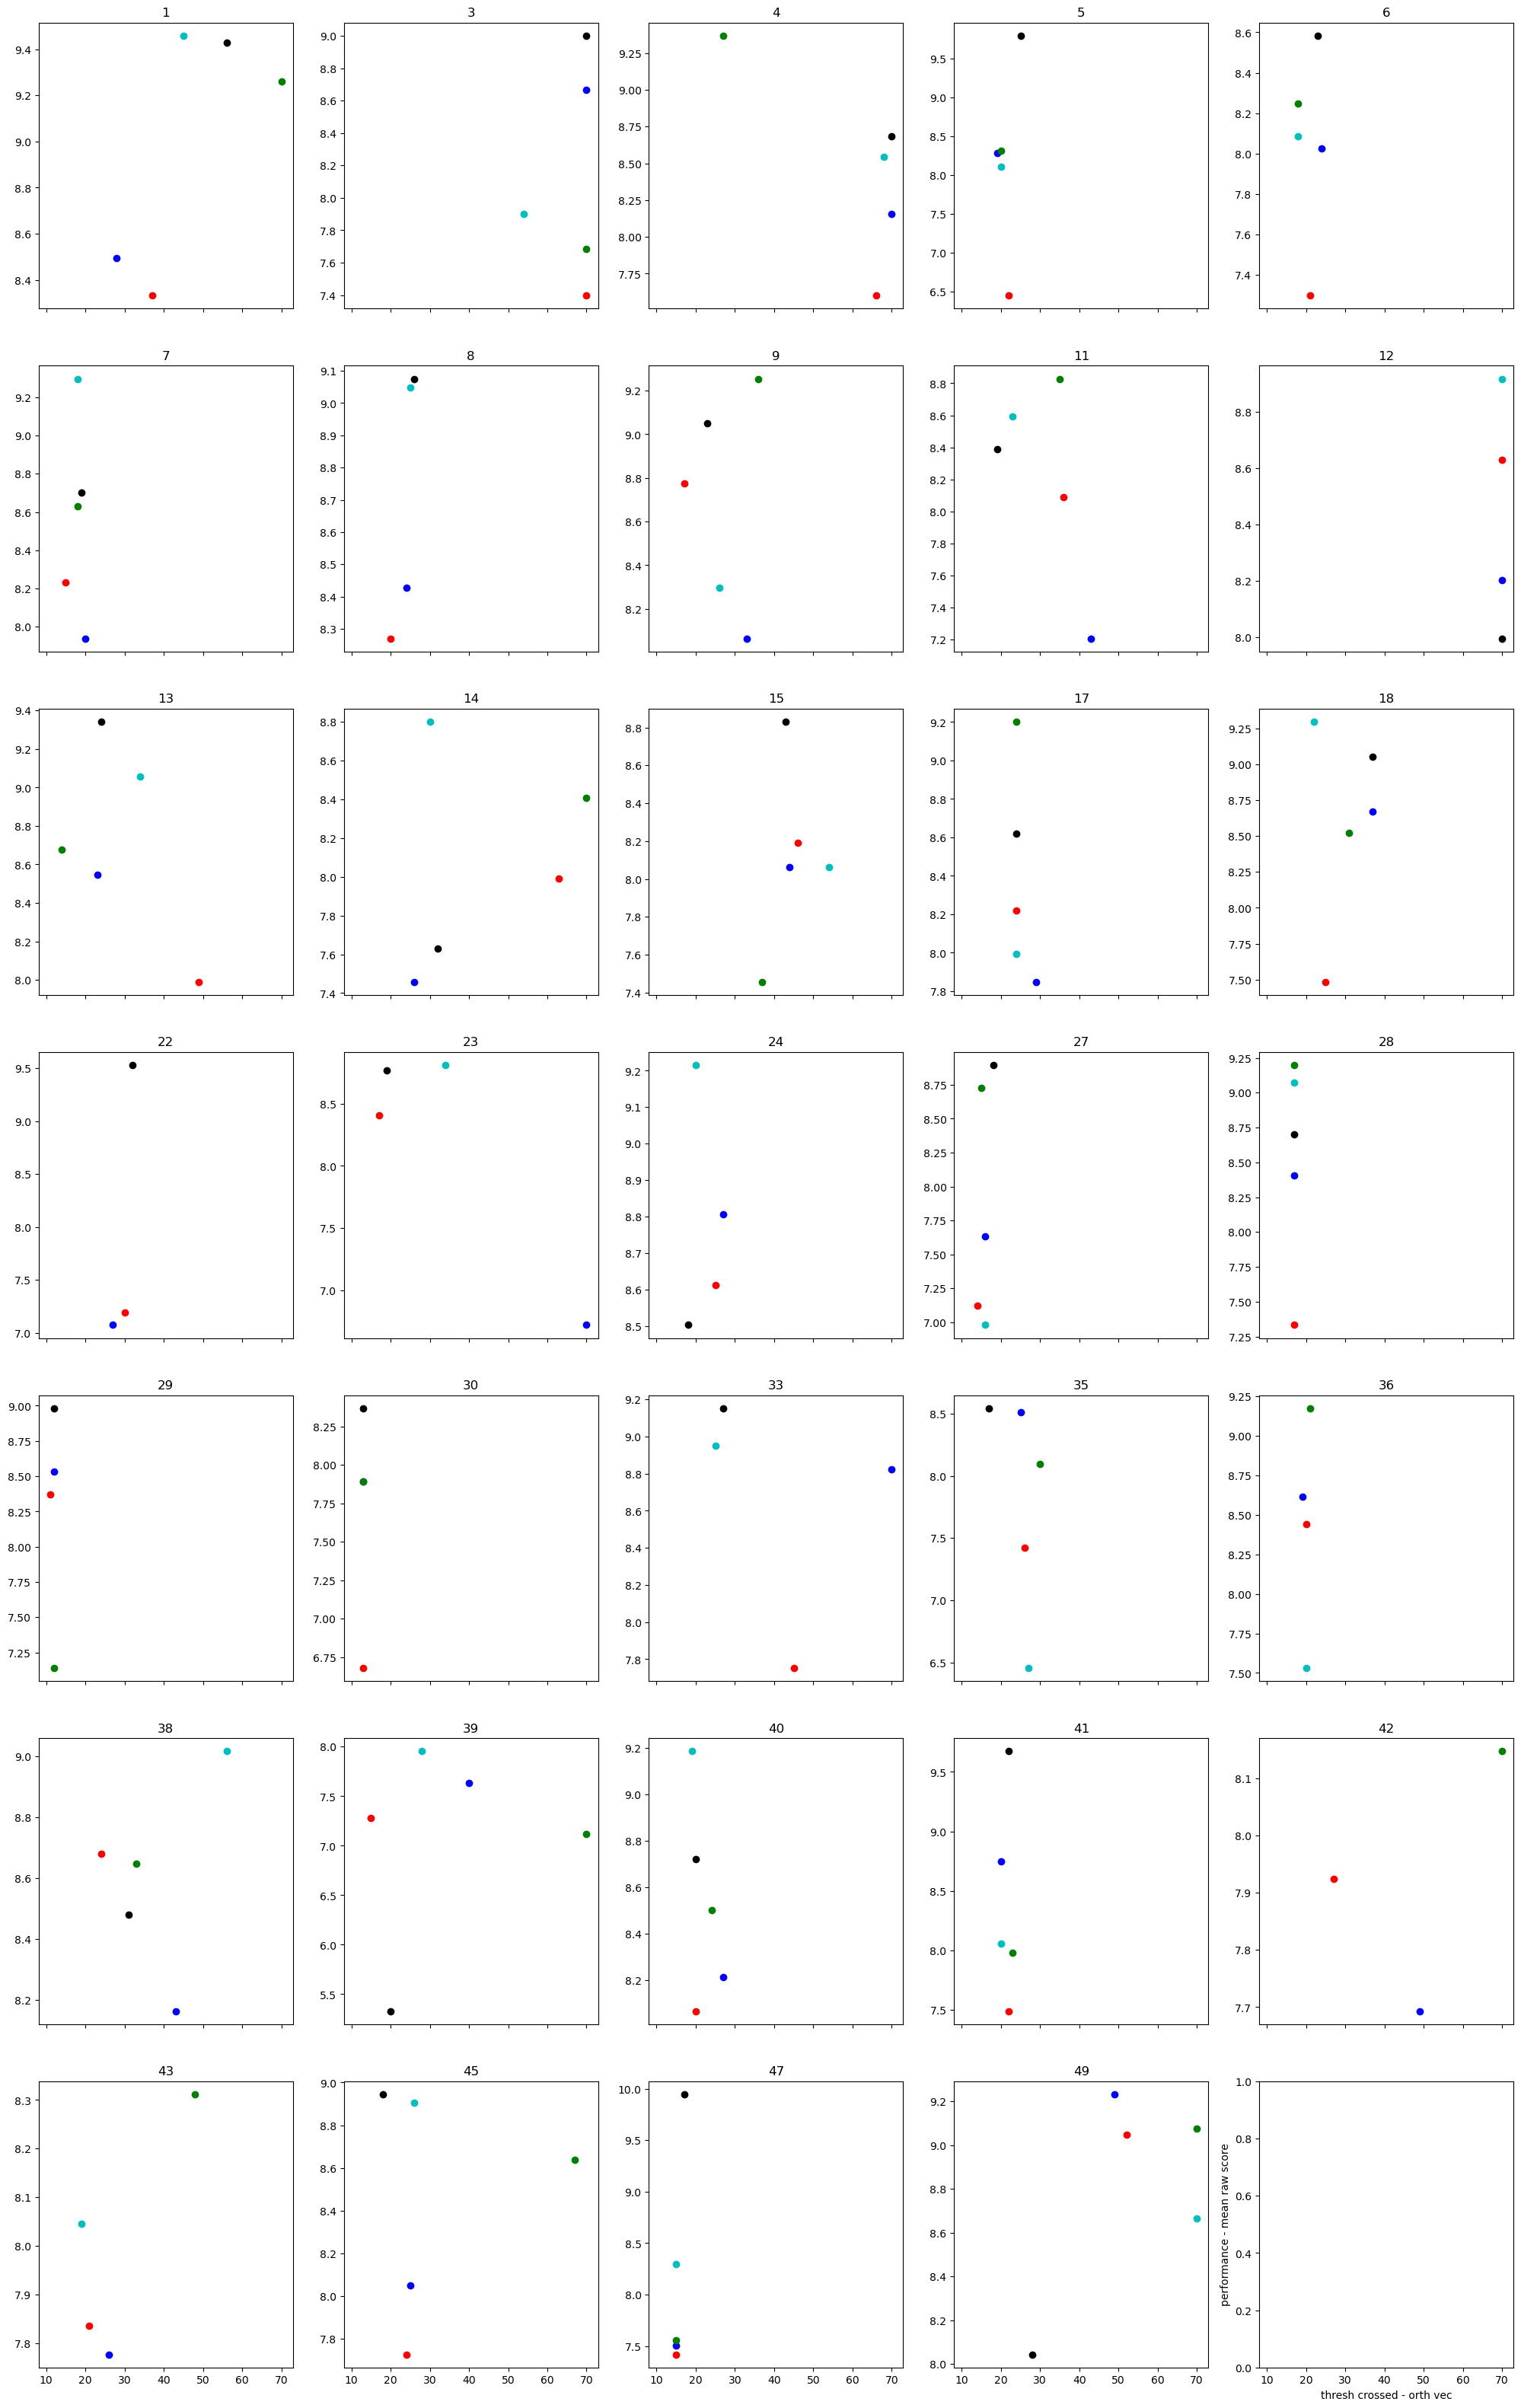

In [37]:
fig, ax = plt.subplots(7,5, figsize=(25,40), sharex=True)
for i,t in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        raw_score = mean_results[t][seed]['raw_score']
        if raw_score is None:
            continue
        #idx = mean_results[t][seed]['raw_score'].index.to_list()
        ax[i//5, i%5].scatter(mc_measures['orth_vec_thresh_crossed_not_norm'][t][seed], mean_raw_score_time_interval[t][seed], c=colors[j])
        ax[i//5, i%5].set_title(f'{t}')
        plt.xlabel('thresh crossed - orth vec')
        plt.ylabel('performance - mean raw score')

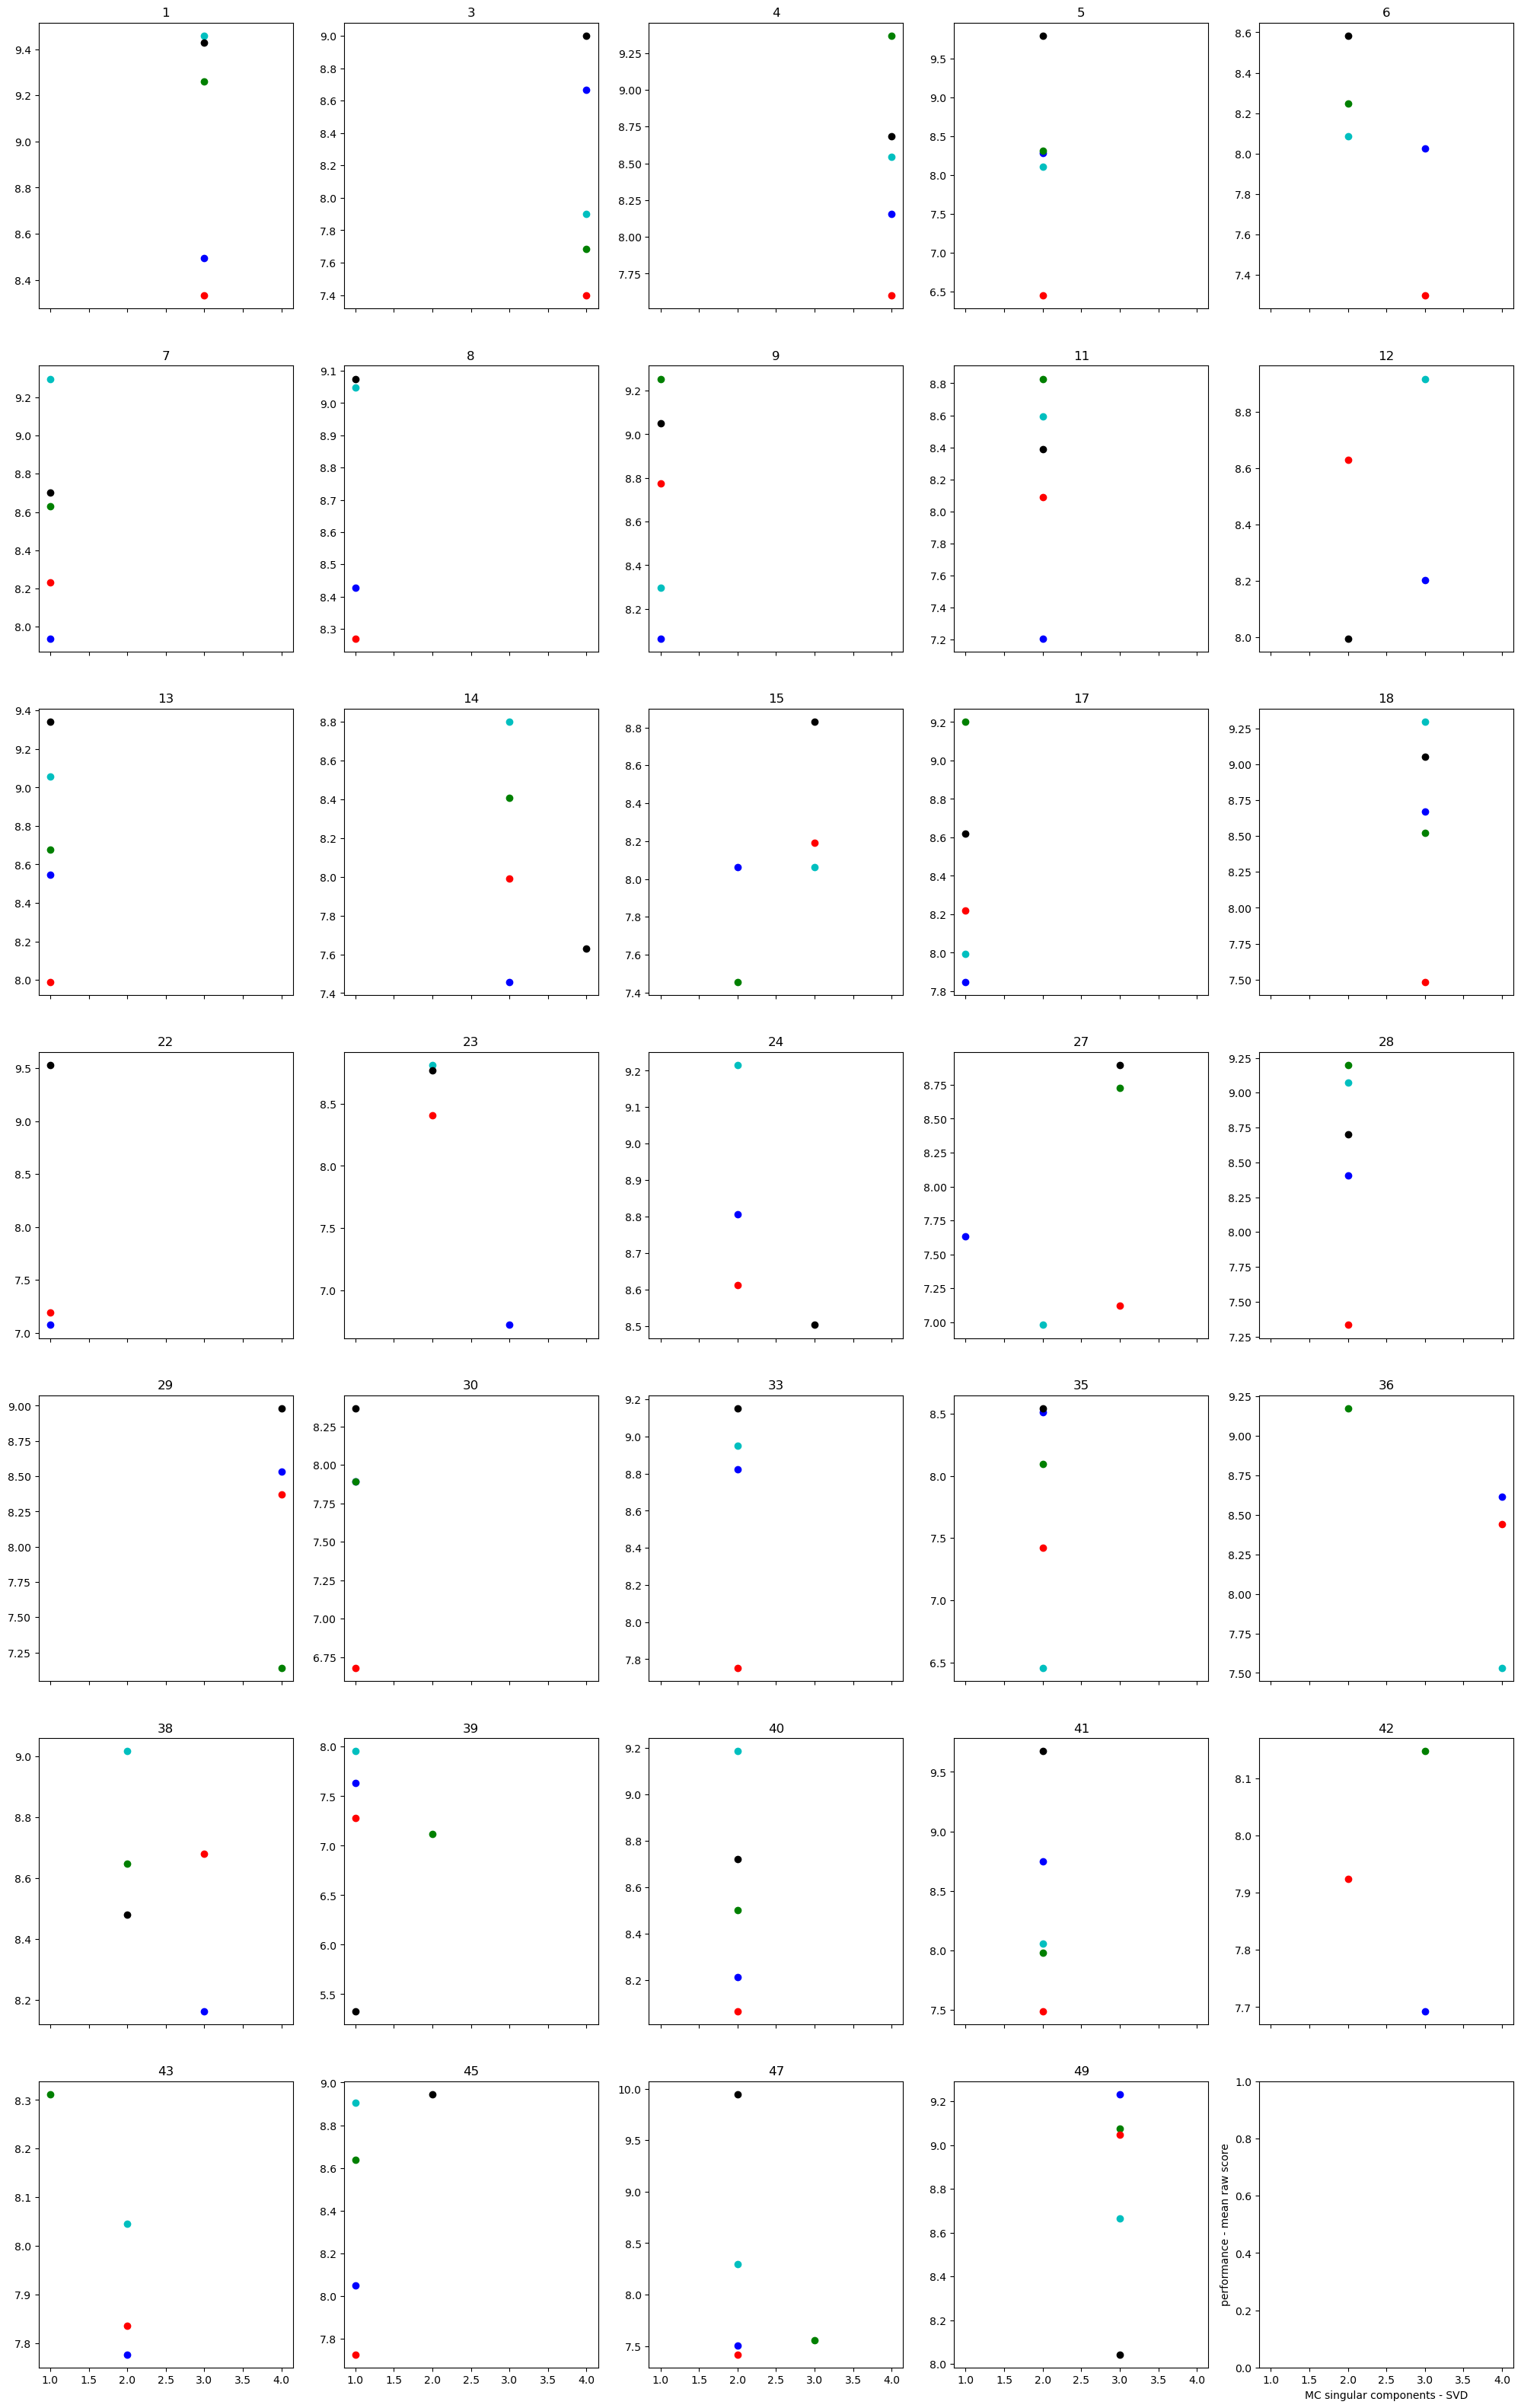

In [38]:
fig, ax = plt.subplots(7,5, figsize=(25,40), sharex=True)
for i,t in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        raw_score = mean_results[t][seed]['raw_score']
        if raw_score is None:
            continue
        #idx = mean_results[t][seed]['raw_score'].index.to_list()
        ax[i//5, i%5].scatter(mc_measures['MC_singular_components_svd'][t][seed], mean_raw_score_time_interval[t][seed], c=colors[j])
        ax[i//5, i%5].set_title(f'{t}')
        plt.xlabel('MC singular components - SVD')
        plt.ylabel('performance - mean raw score')

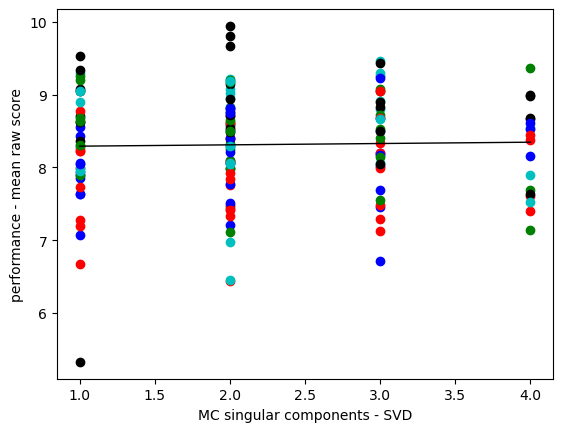

In [34]:
plt.figure()
#plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
for i,trial in enumerate(weight_trials):
    for j,seed in enumerate(seeds):
        if mean_raw_score_time_interval[trial][seed] == None:
            continue
        plt.scatter(mc_measures['MC_singular_components_svd'][trial][seed], mean_raw_score_time_interval[trial][seed], c=colors[j])
plt.xlabel('MC singular components - SVD')
plt.ylabel('performance - mean raw score')

# fit a linear regression
x, y = [], []
for i, trial in enumerate(weight_trials):
    for seed in seeds:
        x.append(mc_measures['MC_singular_components_svd'][trial][seed])
        y.append(mean_raw_score_time_interval[trial][seed])

x = np.asarray(x, float)
y = np.asarray(y, float)
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

reg = LinearRegression().fit(x.reshape(-1, 1), y)
x = np.linspace(x.min(), x.max(), 200)
plt.plot(x, reg.coef_[0]*x + reg.intercept_, color='black', linewidth=1)